Removed no burn in
Removed no burn in
Removed no burn in


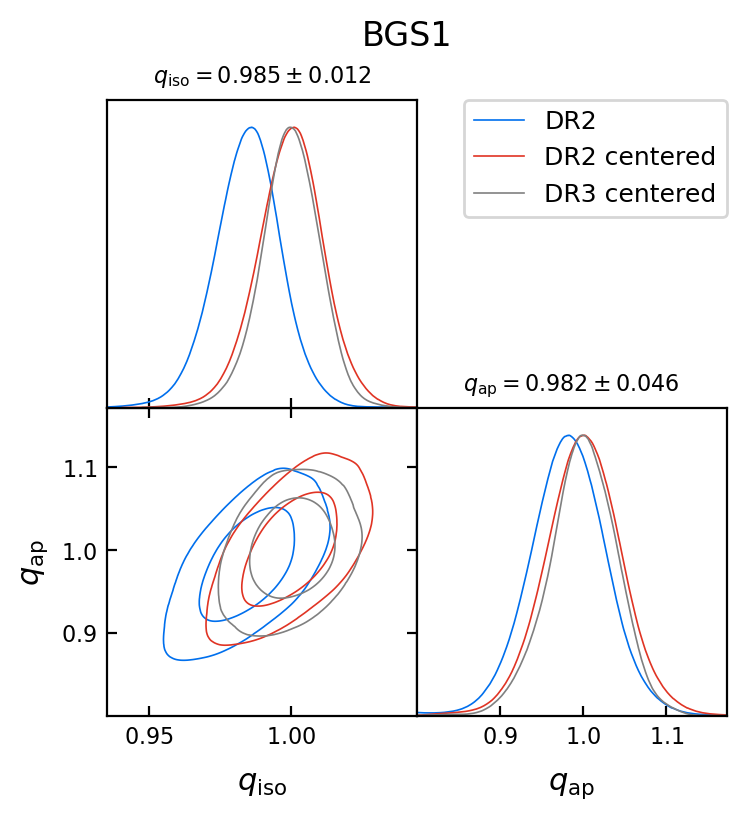

Removed no burn in
Removed no burn in
Removed no burn in


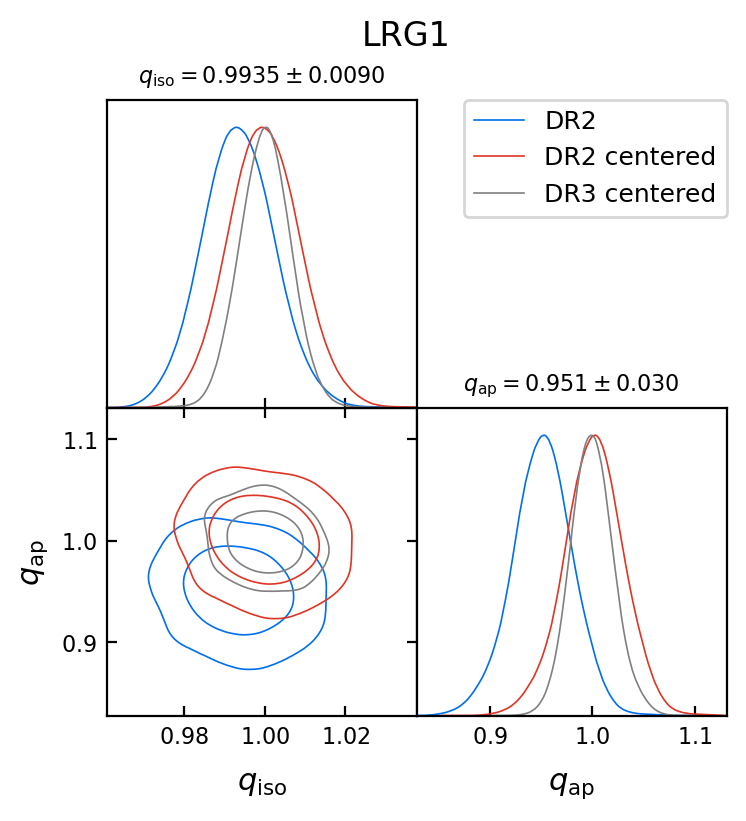

Removed no burn in
Removed no burn in
Removed no burn in


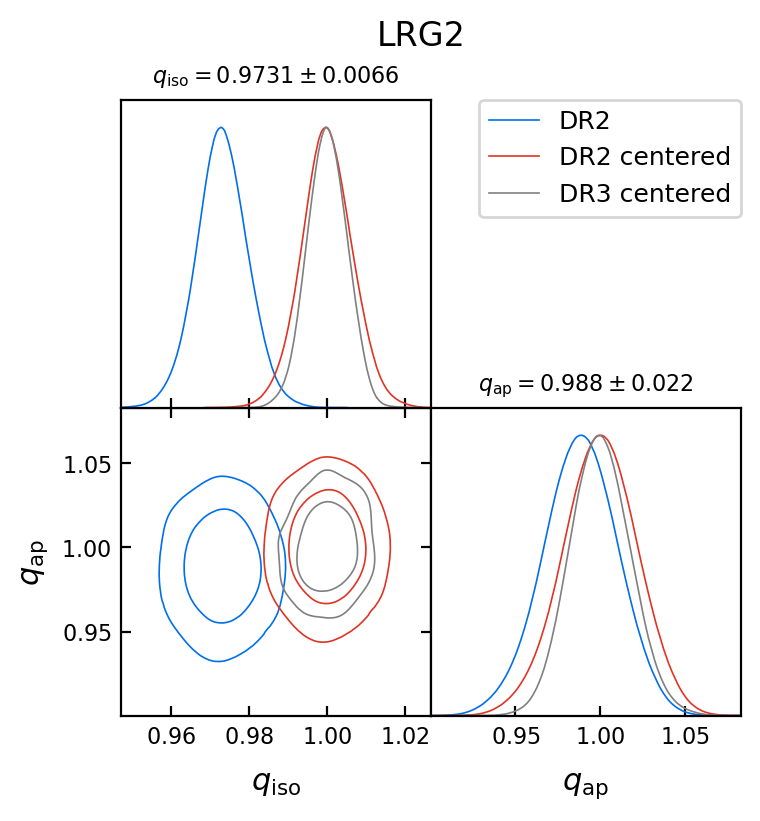

Removed no burn in
Removed no burn in
Removed no burn in


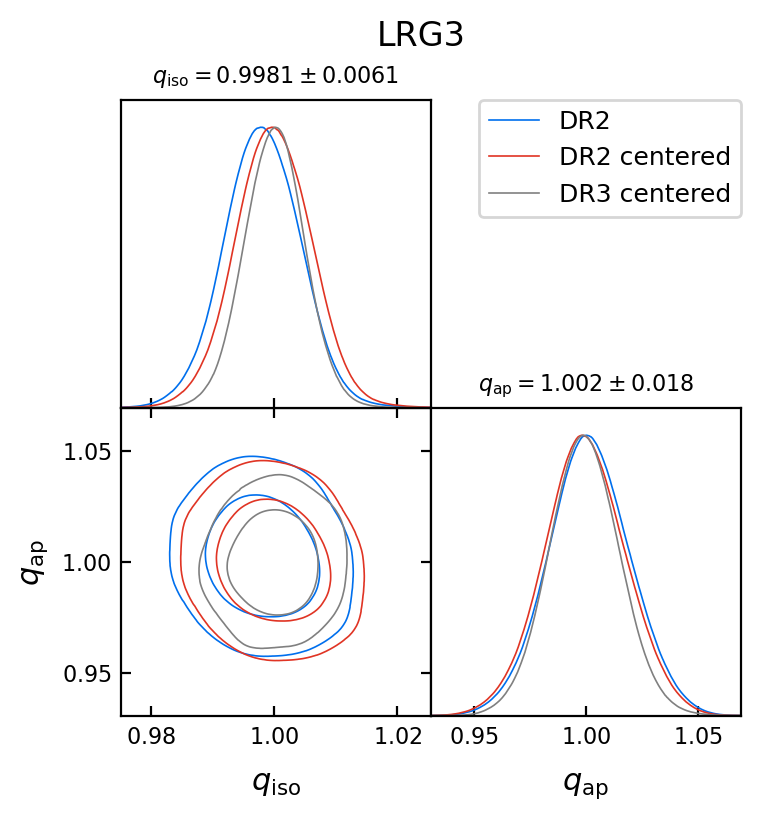

Removed no burn in
Removed no burn in
Removed no burn in


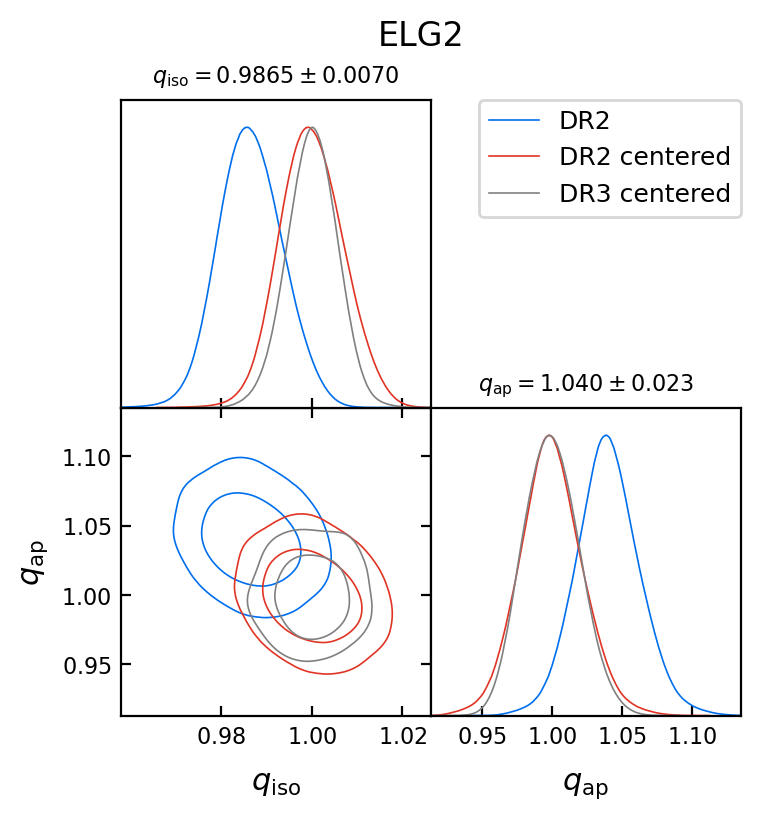

Removed no burn in
Removed no burn in
Removed no burn in


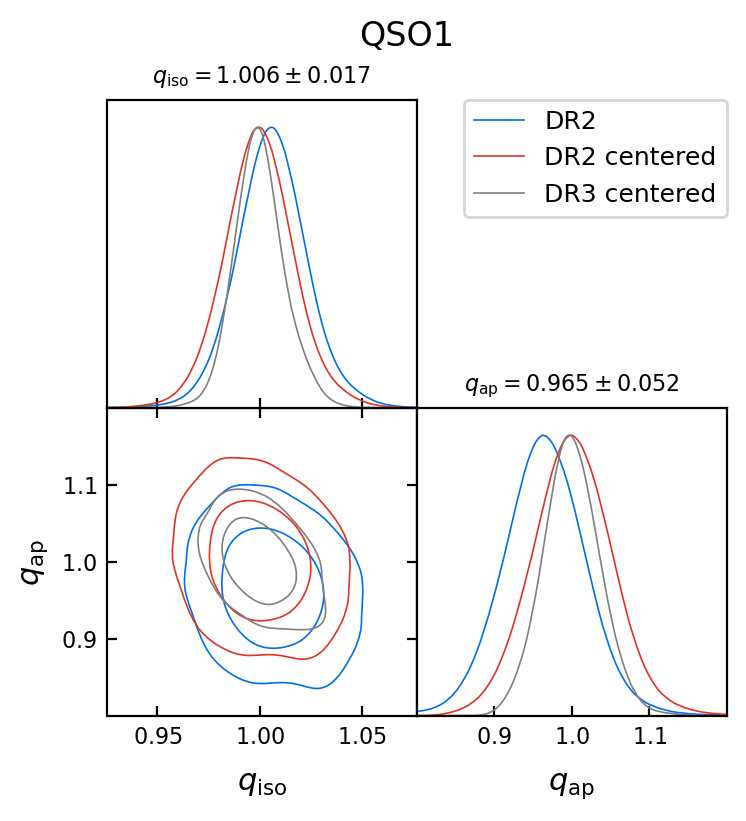

In [1]:
from collections import defaultdict
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

from desilike.samples import MCSamples, Profiles, plotting
from cosmoprimo.fiducial import AbacusSummit

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

params_toplot = ['qiso', 'qap']

truth = {}


def read_samples(fn, burnin=False, thin=False):
    if isinstance(fn, list):
        samples = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin if burnin else 0.) for fn in fn])
    else:
        samples = MCSamples.read(fn)
    if thin:
        samples = samples[::thin]
    return samples


fits_dir = Path('/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/fits/bao')
dir_dr2 = fits_dir / 'with_desi-clustering/data-dr2-v1.1'
dir_dr2_centered = fits_dir / 'centered_alpha/data-dr2-v1.1'
dir_dr3_centered = fits_dir / 'centered_alpha/data-dr3-matterhorn-v2-v0-bao'

stats = defaultdict(list)
tracers = []
for tracer, (basename_dr2, basename_dr3) in {'BGS1': ('template-bao_BGS1-C2R-04031e03', 'template-bao_BGS1-C2R-31837ac6'),
                                             'LRG1': ('template-bao_LRG1-C2R-87f87260', 'template-bao_LRG1-C2R-c100abcd'),
                                             'LRG2': ('template-bao_LRG2-C2R-a9326aab', 'template-bao_LRG2-C2R-6a927f07'),
                                             'LRG3': ('template-bao_LRG3-C2R-ceab2a2e', 'template-bao_LRG3-C2R-247dbe07'),
                                             'ELG2': ('template-bao_ELG2-C2R-0813091f', 'template-bao_ELG2-C2R-bdf67e3a'),
                                             'QSO1': ('template-bao_QSO1-C2R-8eba6faa', 'template-bao_QSO1-C2R-115ad56b')}.items():
    samples, legends = [], []
    samples.append(read_samples([dir_dr2 / f'{basename_dr2}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append('DR2')
    samples.append(read_samples([dir_dr2_centered / f'{basename_dr2}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append('DR2 centered')
    samples.append(read_samples([dir_dr3_centered / f'{basename_dr3}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append('DR3 centered')
    mean, cov = samples[-1].mean(params=params_toplot), samples[-1].covariance(params=params_toplot)
    plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
    fig = plt.gcf()
    fig.suptitle(tracer)
    plt.show()
    tracers.append(tracer)
    for sample, label in zip(samples, legends):
        stats[(label, 'qiso')].append(sample.std('qiso'))
        stats[(label, 'qap')].append(sample.std('qap'))

In [2]:
ratio_qiso = np.array(stats[('DR3 centered', 'qiso')]) / np.array(stats[('DR2', 'qiso')])
ratio_qap  = np.array(stats[('DR3 centered', 'qap')])  / np.array(stats[('DR2', 'qap')])

print("Tracer   qiso ratio   qap ratio")
for tracer, rqiso, rqap in zip(tracers, ratio_qiso, ratio_qap):
    print(f"{tracer:5s}   {rqiso:.3f}        {rqap:.3f}")

Tracer   qiso ratio   qap ratio
BGS1    0.868        0.892
LRG1    0.698        0.704
LRG2    0.772        0.809
LRG3    0.794        0.862
ELG2    0.792        0.874
QSO1    0.712        0.703


### Covariance comparison

Removed no burn in
Removed no burn in


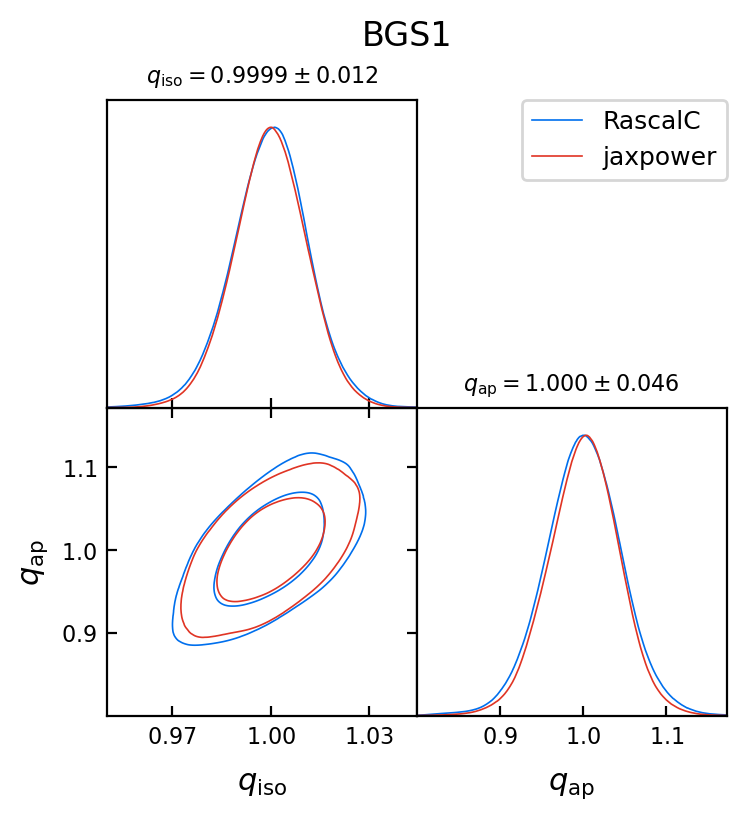

Removed no burn in
Removed no burn in


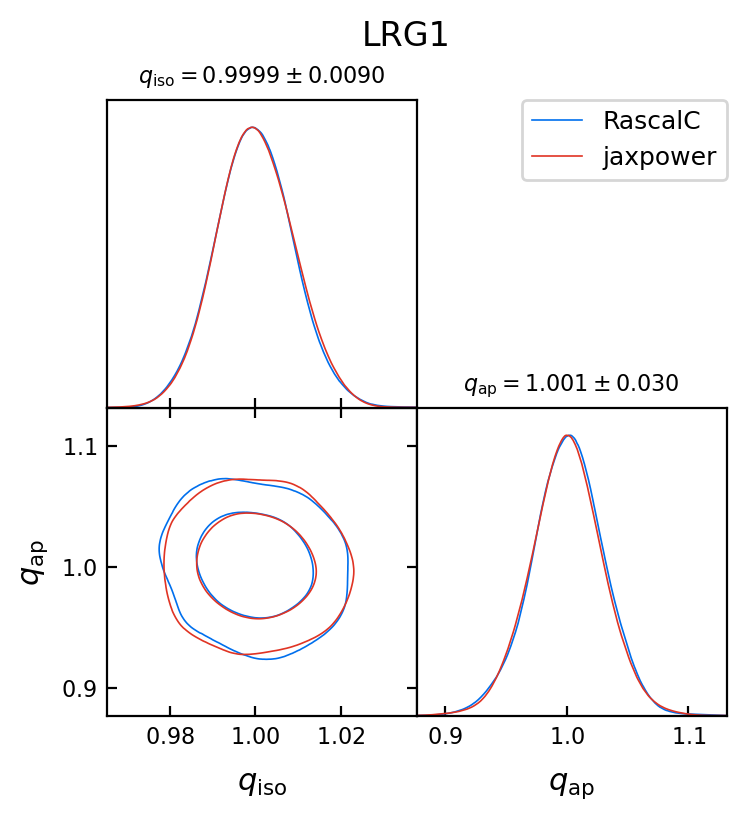

Removed no burn in
Removed no burn in


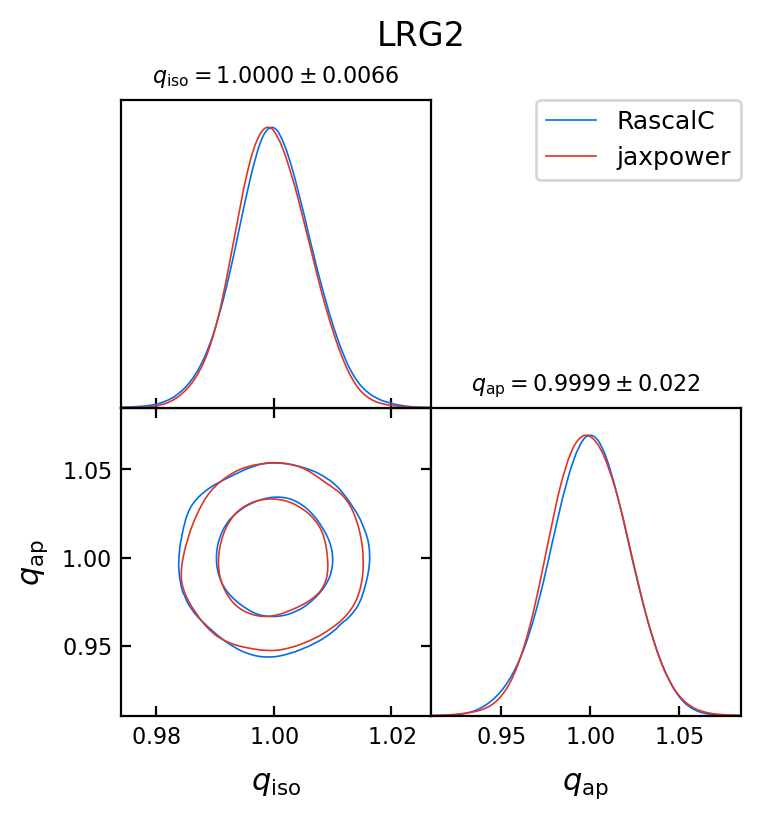

Removed no burn in
Removed no burn in


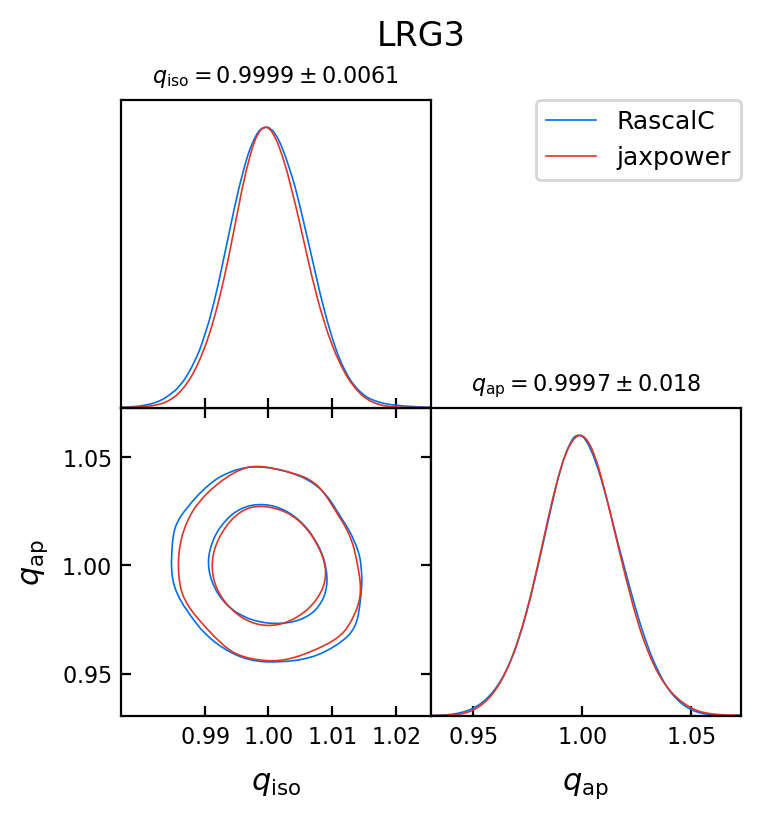

Removed no burn in
Removed no burn in


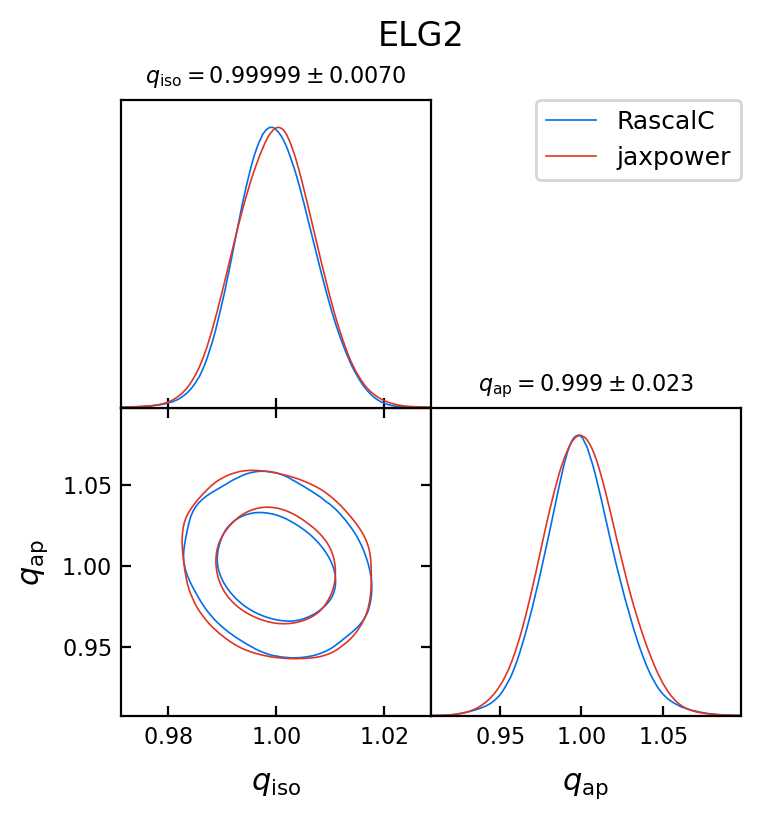

Removed no burn in
Removed no burn in


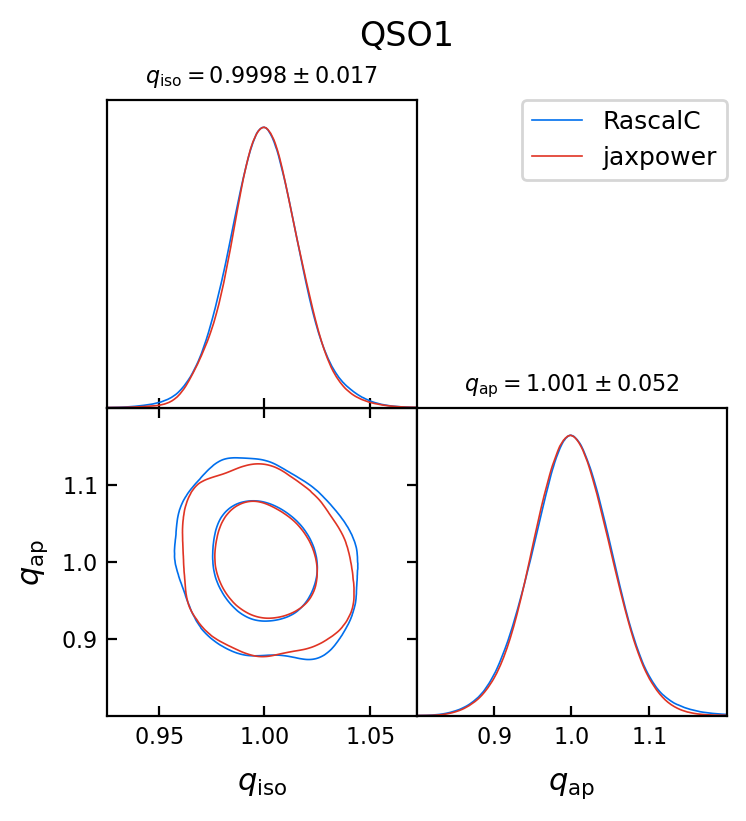

Tracer   qiso ratio   qap ratio
BGS1    0.935        0.918
LRG1    1.005        0.993
LRG2    0.954        0.995
LRG3    0.947        0.998
ELG2    1.045        1.054
QSO1    0.963        0.961


In [3]:
fits_dir = Path('/dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/fits/bao')
dir_dr2_centered = fits_dir / 'centered_alpha/data-dr2-v1.1'

stats = defaultdict(list)
tracers = []
for tracer, (basename_rascalc, basename_jaxpower) in {'BGS1': ('template-bao_BGS1-C2R-04031e03', 'template-bao_BGS1-C2R-81960a56'),
                                             'LRG1': ('template-bao_LRG1-C2R-87f87260', 'template-bao_LRG1-C2R-d0b68470'),
                                             'LRG2': ('template-bao_LRG2-C2R-a9326aab', 'template-bao_LRG2-C2R-8910d425'),
                                             'LRG3': ('template-bao_LRG3-C2R-ceab2a2e', 'template-bao_LRG3-C2R-ef1825f6'),
                                             'ELG2': ('template-bao_ELG2-C2R-0813091f', 'template-bao_ELG2-C2R-0a73e83c'),
                                             'QSO1': ('template-bao_QSO1-C2R-8eba6faa', 'template-bao_QSO1-C2R-1d44ab1f')}.items():
    samples, legends = [], []
    samples.append(read_samples([dir_dr2_centered / f'{basename_rascalc}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append('RascalC')
    samples.append(read_samples([dir_dr2_centered / f'{basename_jaxpower}/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.5, thin=10))
    legends.append('jaxpower')
    plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
    fig = plt.gcf()
    fig.suptitle(tracer)
    plt.show()
    tracers.append(tracer)
    for sample, label in zip(samples, legends):
        stats[(label, 'qiso')].append(sample.std('qiso'))
        stats[(label, 'qap')].append(sample.std('qap'))

ratio_qiso = np.array(stats[('jaxpower', 'qiso')]) / np.array(stats[('RascalC', 'qiso')])
ratio_qap  = np.array(stats[('jaxpower', 'qap')])  / np.array(stats[('RascalC', 'qap')])

print("Tracer   qiso ratio   qap ratio")
for tracer, rqiso, rqap in zip(tracers, ratio_qiso, ratio_qap):
    print(f"{tracer:5s}   {rqiso:.3f}        {rqap:.3f}")